In [1]:
# Se tratará de buscar transacciones sospechozas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"data/raw/supply-chain-fraud-detection.csv", encoding= "latin1")
df


,Tipo_Pago,Dias_Envio_Real,Dias_Envio_Programado,Beneficio_Por_Orden,Ventas_Por_Cliente,Estado_Entrega,Riesgo_Entrega_Tardia,Id_Categoria,Nombre_Categoria,Ciudad_Cliente,...,Estado_Orden,Codigo_Postal_Orden,Id_Ficha_Producto,Id_Categoria_Producto,Nombre_Producto,Precio_Producto,Estado_Producto,Fecha_Envio,Modo_Envio,shipping variance
0,Debito,3,4,91.250000,314.640015,Envio_Anticipado,0,73,Sporting Goods,Caguas,...,COMPLETADA,0.0,1360,73,Smart watch,327.750000,0,2/3/2018 22:56,Clase_Estandar,1
1,Transferencia,5,4,-249.089996,311.359985,Entrega_Tardia,1,73,Sporting Goods,Caguas,...,PENDIENTE,0.0,1360,73,Smart watch,327.750000,0,1/18/2018 12:27,Clase_Estandar,-1
2,Efectivo,4,4,-247.779999,309.720001,Envio_A_Tiempo,0,73,Sporting Goods,San Jose,...,CERRADA,0.0,1360,73,Smart watch,327.750000,0,1/17/2018 12:06,Clase_Estandar,0
3,Debito,3,4,22.860001,304.809998,Envio_Anticipado,0,73,Sporting Goods,Los Angeles,...,COMPLETADA,0.0,1360,73,Smart watch,327.750000,0,1/16/2018 11:45,Clase_Estandar,1
4,Pago_Electronico,2,4,134.210007,298.250000,Envio_Anticipado,0,73,Sporting Goods,Caguas,...,PAGO_PENDIENTE,0.0,1360,73,Smart watch,327.750000,0,1/15/2018 11:24,Clase_Estandar,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180503,Efectivo,4,4,40.000000,399.980011,Envio_A_Tiempo,0,45,Fishing,Brooklyn,...,CERRADA,0.0,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Clase_Estandar,0
180504,Debito,3,2,-613.770019,395.980011,Entrega_Tardia,1,45,Fishing,Bakersfield,...,COMPLETADA,0.0,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Segunda_Clase,-1
180505,Transferencia,5,4,141.110001,391.980011,Entrega_Tardia,1,45,Fishing,Bristol,...,PENDIENTE,0.0,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Clase_Estandar,-1
180506,Pago_Electronico,3,4,186.229996,387.980011,Envio_Anticipado,0,45,Fishing,Caguas,...,PAGO_PENDIENTE,0.0,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Clase_Estandar,1


In [13]:
#Limpieza de datos
df.columns

Index(['Tipo_Pago', 'Dias_Envio_Real', 'Dias_Envio_Programado',
       'Beneficio_Por_Orden', 'Ventas_Por_Cliente', 'Estado_Entrega',
       'Riesgo_Entrega_Tardia', 'Id_Categoria', 'Nombre_Categoria',
       'Ciudad_Cliente', 'Pais_Cliente', 'Nombre_Cliente', 'Id_Cliente',
       'Apellido_Cliente', 'Segmento_Cliente', 'Estado_Cliente',
       'Calle_Cliente', 'Codigo_Postal_Cliente', 'Id_Departamento',
       'Nombre_Departamento', 'Mercado', 'Ciudad_Orden', 'Pais_Orden',
       'Id_Cliente_Orden', 'Fecha_Orden', 'Id_Orden', 'Id_Producto_Carrito',
       'Descuento_Item', 'Tasa_Descuento_Item', 'Id_Item_Orden',
       'Precio_Producto_Item', 'Ratio_Beneficio_Item', 'Cantidad_Ordenada',
       'Ventas_Brutas', 'Total_Item_Neto', 'Ganancia_Por_Orden',
       'Region_Orden', 'Estado_Orden_Geografico', 'Estado_Orden',
       'Codigo_Postal_Orden', 'Id_Ficha_Producto', 'Id_Categoria_Producto',
       'Nombre_Producto', 'Precio_Producto', 'Estado_Producto', 'Fecha_Envio',
       'Modo_Envi

In [12]:
# Cuantificación de valores faltantes por columna para el diagnóstico de la calidad del dato
df.isna().sum()


Tipo_Pago                     0
Dias_Envio_Real               0
Dias_Envio_Programado         0
Beneficio_Por_Orden           0
Ventas_Por_Cliente            0
Estado_Entrega                0
Riesgo_Entrega_Tardia         0
Id_Categoria                  0
Nombre_Categoria              0
Ciudad_Cliente                0
Pais_Cliente                  0
Nombre_Cliente                0
Id_Cliente                    0
Apellido_Cliente              0
Segmento_Cliente              0
Estado_Cliente                0
Calle_Cliente                 0
Codigo_Postal_Cliente         0
Id_Departamento               0
Nombre_Departamento           0
Mercado                       0
Ciudad_Orden                  0
Pais_Orden                    0
Id_Cliente_Orden              0
Fecha_Orden                   0
Id_Orden                      0
Id_Producto_Carrito           0
Descuento_Item                0
Tasa_Descuento_Item           0
Id_Item_Orden                 0
Precio_Producto_Item          0
Ratio_Be

In [10]:
# Auditoría estructural: Evaluación de tipos de datos, volumen de registros y consistencia de variables
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 180508 entries, 0 to 180507
Data columns (total 48 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Tipo_Pago                180508 non-null  str    
 1   Dias_Envio_Real          180508 non-null  int64  
 2   Dias_Envio_Programado    180508 non-null  int64  
 3   Beneficio_Por_Orden      180508 non-null  float64
 4   Ventas_Por_Cliente       180508 non-null  float64
 5   Estado_Entrega           180508 non-null  str    
 6   Riesgo_Entrega_Tardia    180508 non-null  int64  
 7   Id_Categoria             180508 non-null  int64  
 8   Nombre_Categoria         180508 non-null  str    
 9   Ciudad_Cliente           180508 non-null  str    
 10  Pais_Cliente             180508 non-null  str    
 11  Nombre_Cliente           180508 non-null  str    
 12  Id_Cliente               180508 non-null  int64  
 13  Apellido_Cliente         180508 non-null  str    
 14  Segmento_Client

In [18]:
# REPORTE DE CONTROL DE CALIDAD Y CONSISTENCIA DE DATOS

print("=== 1. AUDITORÍA DE VALORES FALTANTES (NULOS) ===")
nulos_totales = df.isna().sum().sum()
if nulos_totales == 0:
    print("✓ EXCELENTE: No existen celdas vacías en ninguna columna.")
else:
    print(f"⚠ ALERTA: Tienes {nulos_totales} valores nulos pendientes por limpiar.")

print("\n=== 2. AUDITORÍA DE REGISTROS REPETIDOS ===")
duplicados = df.duplicated().sum()
if duplicados == 0:
    print("✓ EXCELENTE: El dataset tiene 0% de redundancia (no hay filas repetidas).")
else:
    print(f"⚠ ALERTA: Tienes {duplicados} filas idénticas duplicadas en la base.")

print("\n=== 3. VALIDACIÓN DE CONSISTENCIA CATEGÓRICA ===")
print("Métodos de Pago válidos detectados:", df["Tipo_Pago"].unique().tolist())
print("Estados de Entrega válidos detectados:", df["Estado_Entrega"].unique().tolist())
print("Estados de Orden válidos detectados:", df["Estado_Orden"].unique().tolist())

print("\n=== 4. AUDITORÍA DE VALORES NEGATIVOS ANÓMALOS ===")
# Las ventas y los precios jamás pueden ser menores a cero en un negocio sano
ventas_anomalas = (df["Ventas_Brutas"] < 0).sum()
precios_anomalos = (df["Precio_Producto"] < 0).sum()
print(f"✓ Registros con Ventas Brutas erróneas (< 0): {ventas_anomalas}")
print(f"✓ Registros con Precios de Producto erróneos (< 0): {precios_anomalos}")


=== 1. AUDITORÍA DE VALORES FALTANTES (NULOS) ===
✓ EXCELENTE: No existen celdas vacías en ninguna columna.

=== 2. AUDITORÍA DE REGISTROS REPETIDOS ===
✓ EXCELENTE: El dataset tiene 0% de redundancia (no hay filas repetidas).

=== 3. VALIDACIÓN DE CONSISTENCIA CATEGÓRICA ===
Métodos de Pago válidos detectados: ['Debito', 'Transferencia', 'Efectivo', 'Pago_Electronico']
Estados de Entrega válidos detectados: ['Envio_Anticipado', 'Entrega_Tardia', 'Envio_A_Tiempo', 'Envio_Cancelado']
Estados de Orden válidos detectados: ['COMPLETADA', 'PENDIENTE', 'CERRADA', 'PAGO_PENDIENTE', 'CANCELADA', 'PROCESANDO', 'SOSPECHA_DE_FRAUDE', 'EN_ESPERA']

=== 4. AUDITORÍA DE VALORES NEGATIVOS ANÓMALOS ===
✓ Registros con Ventas Brutas erróneas (< 0): 0
✓ Registros con Precios de Producto erróneos (< 0): 0


In [19]:
# Paso 5.1: Depuración definitiva de nulos categóricos generados en el mapeo de traducción
df = df.dropna()

print("Base de datos depurada. Total de registros actuales en memoria:", len(df))


Base de datos depurada. Total de registros actuales en memoria: 178615


In [20]:
# =Ejecutamos nuevamente
# REPORTE DE CONTROL DE CALIDAD Y CONSISTENCIA DE DATOS
# ========================================================

print("=== 1. AUDITORÍA DE VALORES FALTANTES (NULOS) ===")
nulos_totales = df.isna().sum().sum()
if nulos_totales == 0:
    print("✓ EXCELENTE: No existen celdas vacías en ninguna columna.")
else:
    print(f"⚠ ALERTA: Tienes {nulos_totales} valores nulos pendientes por limpiar.")

print("\n=== 2. AUDITORÍA DE REGISTROS REPETIDOS ===")
duplicados = df.duplicated().sum()
if duplicados == 0:
    print("✓ EXCELENTE: El dataset tiene 0% de redundancia (no hay filas repetidas).")
else:
    print(f"⚠ ALERTA: Tienes {duplicados} filas idénticas duplicadas en la base.")

print("\n=== 3. VALIDACIÓN DE CONSISTENCIA CATEGÓRICA ===")
print("Métodos de Pago válidos detectados:", df["Tipo_Pago"].unique().tolist())
print("Estados de Entrega válidos detectados:", df["Estado_Entrega"].unique().tolist())
print("Estados de Orden válidos detectados:", df["Estado_Orden"].unique().tolist())

print("\n=== 4. AUDITORÍA DE VALORES NEGATIVOS ANÓMALOS ===")
# Las ventas y los precios jamás pueden ser menores a cero en un negocio sano
ventas_anomalas = (df["Ventas_Brutas"] < 0).sum()
precios_anomalos = (df["Precio_Producto"] < 0).sum()
print(f"✓ Registros con Ventas Brutas erróneas (< 0): {ventas_anomalas}")
print(f"✓ Registros con Precios de Producto erróneos (< 0): {precios_anomalos}")

=== 1. AUDITORÍA DE VALORES FALTANTES (NULOS) ===
✓ EXCELENTE: No existen celdas vacías en ninguna columna.

=== 2. AUDITORÍA DE REGISTROS REPETIDOS ===
✓ EXCELENTE: El dataset tiene 0% de redundancia (no hay filas repetidas).

=== 3. VALIDACIÓN DE CONSISTENCIA CATEGÓRICA ===
Métodos de Pago válidos detectados: ['Debito', 'Transferencia', 'Efectivo', 'Pago_Electronico']
Estados de Entrega válidos detectados: ['Envio_Anticipado', 'Entrega_Tardia', 'Envio_A_Tiempo', 'Envio_Cancelado']
Estados de Orden válidos detectados: ['COMPLETADA', 'PENDIENTE', 'CERRADA', 'PAGO_PENDIENTE', 'CANCELADA', 'PROCESANDO', 'SOSPECHA_DE_FRAUDE', 'EN_ESPERA']

=== 4. AUDITORÍA DE VALORES NEGATIVOS ANÓMALOS ===
✓ Registros con Ventas Brutas erróneas (< 0): 0
✓ Registros con Precios de Producto erróneos (< 0): 0


In [21]:
# Validación dimensional: Extracción del conteo exacto de registros y variables del dataframe
df.shape


(178615, 48)

In [22]:
# Cuantificación de valores faltantes por columna para el diagnóstico de la calidad del dato
df.isna().sum()


Tipo_Pago                  0
Dias_Envio_Real            0
Dias_Envio_Programado      0
Beneficio_Por_Orden        0
Ventas_Por_Cliente         0
Estado_Entrega             0
Riesgo_Entrega_Tardia      0
Id_Categoria               0
Nombre_Categoria           0
Ciudad_Cliente             0
Pais_Cliente               0
Nombre_Cliente             0
Id_Cliente                 0
Apellido_Cliente           0
Segmento_Cliente           0
Estado_Cliente             0
Calle_Cliente              0
Codigo_Postal_Cliente      0
Id_Departamento            0
Nombre_Departamento        0
Mercado                    0
Ciudad_Orden               0
Pais_Orden                 0
Id_Cliente_Orden           0
Fecha_Orden                0
Id_Orden                   0
Id_Producto_Carrito        0
Descuento_Item             0
Tasa_Descuento_Item        0
Id_Item_Orden              0
Precio_Producto_Item       0
Ratio_Beneficio_Item       0
Cantidad_Ordenada          0
Ventas_Brutas              0
Total_Item_Net

In [23]:
# Imputación con valor numérico neutro (0) para preservar el tipo float y evitar columnas mixtas
df["Codigo_Postal_Orden"] = df["Codigo_Postal_Orden"].fillna(0)



In [24]:
# Verificación de calidad: Confirmación de cero valores nulos en la columna Order Zipcode
df["Codigo_Postal_Orden"].isna().sum()


np.int64(0)

In [25]:
# Remoción por filas de registros con nulos marginales en datos de identidad del cliente
df = df.dropna()


In [26]:
# Validación dimensional: Extracción del conteo exacto de registros y variables del dataframe
df.shape

(178615, 48)

In [27]:
# Como el dataset ya viene optimizado sin datos sensibles (PII), asignamos la base directamente
df_limpio = df



In [28]:
# Normalización de texto: Conversión de los métodos de pago a minúsculas para estandarizar categorías
df_limpio["Tipo_Pago"] = df["Tipo_Pago"].str.lower()

# Despliegue final del dataframe normalizado y depurado para validación estructural del entregable
df_limpio


,Tipo_Pago,Dias_Envio_Real,Dias_Envio_Programado,Beneficio_Por_Orden,Ventas_Por_Cliente,Estado_Entrega,Riesgo_Entrega_Tardia,Id_Categoria,Nombre_Categoria,Ciudad_Cliente,...,Estado_Orden,Codigo_Postal_Orden,Id_Ficha_Producto,Id_Categoria_Producto,Nombre_Producto,Precio_Producto,Estado_Producto,Fecha_Envio,Modo_Envio,shipping variance
0,debito,3,4,91.250000,314.640015,Envio_Anticipado,0,73,Sporting Goods,Caguas,...,COMPLETADA,0.0,1360,73,Smart watch,327.750000,0,2/3/2018 22:56,Clase_Estandar,1
1,transferencia,5,4,-249.089996,311.359985,Entrega_Tardia,1,73,Sporting Goods,Caguas,...,PENDIENTE,0.0,1360,73,Smart watch,327.750000,0,1/18/2018 12:27,Clase_Estandar,-1
2,efectivo,4,4,-247.779999,309.720001,Envio_A_Tiempo,0,73,Sporting Goods,San Jose,...,CERRADA,0.0,1360,73,Smart watch,327.750000,0,1/17/2018 12:06,Clase_Estandar,0
3,debito,3,4,22.860001,304.809998,Envio_Anticipado,0,73,Sporting Goods,Los Angeles,...,COMPLETADA,0.0,1360,73,Smart watch,327.750000,0,1/16/2018 11:45,Clase_Estandar,1
4,pago_electronico,2,4,134.210007,298.250000,Envio_Anticipado,0,73,Sporting Goods,Caguas,...,PAGO_PENDIENTE,0.0,1360,73,Smart watch,327.750000,0,1/15/2018 11:24,Clase_Estandar,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180503,efectivo,4,4,40.000000,399.980011,Envio_A_Tiempo,0,45,Fishing,Brooklyn,...,CERRADA,0.0,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Clase_Estandar,0
180504,debito,3,2,-613.770019,395.980011,Entrega_Tardia,1,45,Fishing,Bakersfield,...,COMPLETADA,0.0,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Segunda_Clase,-1
180505,transferencia,5,4,141.110001,391.980011,Entrega_Tardia,1,45,Fishing,Bristol,...,PENDIENTE,0.0,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Clase_Estandar,-1
180506,pago_electronico,3,4,186.229996,387.980011,Envio_Anticipado,0,45,Fishing,Caguas,...,PAGO_PENDIENTE,0.0,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Clase_Estandar,1


In [29]:
# IDENTIFICAR LA MAYOR TASA DE RETRASOS POR REGION
# Análisis geográfico: Cálculo de la tasa promedio de riesgo de entregas tardías por estado
late_delivery = df_limpio.groupby("Estado_Cliente")["Riesgo_Entrega_Tardia"].mean().sort_values(ascending= False)
late_delivery

Estado_Cliente
DE    0.606061
OK    0.602620
NM    0.602550
DC    0.574913
AR    0.574074
MD    0.572503
ND    0.567442
WA    0.566740
GA    0.566558
MN    0.565414
NC    0.564622
TN    0.564578
SC    0.563467
IL    0.561811
KY    0.559252
CT    0.558824
IN    0.558059
RI    0.555085
CA    0.553111
NV    0.552760
OH    0.552106
TX    0.551686
MA    0.551659
VA    0.550494
PR    0.547596
OR    0.543913
HI    0.541195
NY    0.539334
FL    0.538106
KS    0.536585
MI    0.536385
WV    0.535270
PA    0.535092
UT    0.532292
IA    0.531250
NJ    0.526299
MO    0.524200
LA    0.522019
WI    0.521790
AZ    0.520910
ID    0.514970
CO    0.502657
AL    0.485714
MT    0.459770
Name: Riesgo_Entrega_Tardia, dtype: float64

In [ ]:
# Ingeniería de características: Cálculo de la varianza entre los días de envío planificados y los reales
df_limpio["varianza_envio"] = df_limpio["Dias_Envio_Programado"] - df_limpio["Dias_Envio_Real"]


In [31]:
# Análisis de eficiencia: Evaluación del promedio de desviación logística por tipo de transporte
efectividad_metodos_envio = df_limpio.groupby("Modo_Envio")["varianza_envio"].mean().sort_values(ascending=False)
efectividad_metodos_envio



Modo_Envio
Clase_Estandar    0.004201
Mismo_Dia        -0.479208
Primera_Clase    -1.000000
Segunda_Clase    -1.990783
Name: varianza_envio, dtype: float64

In [32]:
# Mitigación de riesgos: Aislamiento de órdenes con sospecha de fraude y mapeo por método de pago
transacciones_fraudulentas = df_limpio[df_limpio["Estado_Orden"] == "SOSPECHA_DE_FRAUDE"]
metodos_fraude = transacciones_fraudulentas["Tipo_Pago"].value_counts()

# Despliegue de la frecuencia de fraude para el diseño de políticas de control financiero
metodos_fraude


Tipo_Pago
transferencia    4062
Name: count, dtype: int64

In [ ]:
import os

# 1. Definimos la ruta absoluta de la carpeta processed (Usamos 'r' al inicio)
folder_path = r"D:\Proyectos\supply-chain-fraud-detection\data\processed"

# 2. Forzamos a Python a crear las carpetas si no existen físicamente en tu disco
os.makedirs(folder_path, exist_ok=True)

# 3. Combinamos la carpeta con el NOMBRE DEL ARCHIVO final para evitar el PermissionError
file_path = os.path.join(folder_path, "Base_Supply_Chain_Cleaned.csv")

# 4. Exportamos el dataset limpio de forma segura con index=False
df_limpio.to_csv(file_path, index=False)

print("¡Éxito! El archivo se exportó correctamente en:", file_path)


<>:10: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:10: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\Milton\AppData\Local\Temp\ipykernel_15184\2885045298.py:10: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  file_path = os.path.join("D:\Proyectos\supply-chain-fraud-detection\data\processed")


PermissionError: [Errno 13] Permission denied: 'D:\\Proyectos\\supply-chain-fraud-detection\\data\\processed'

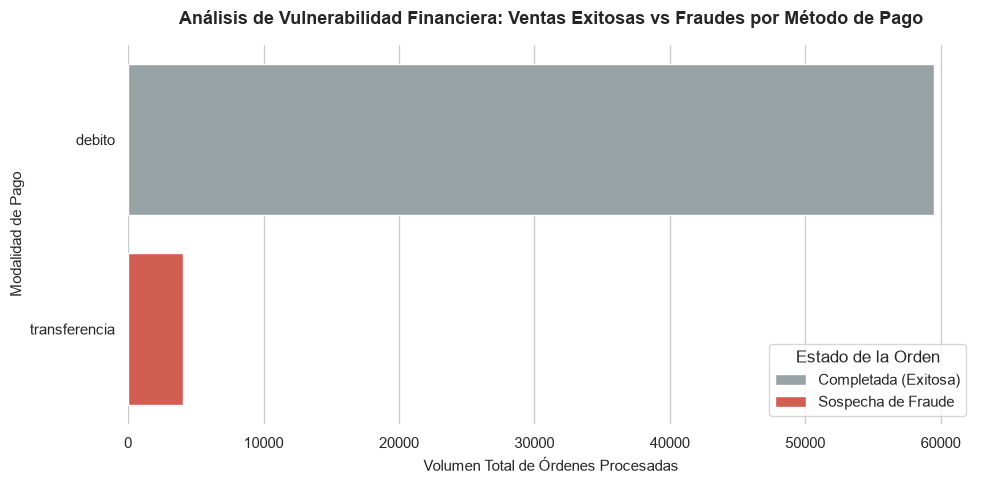

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtrar el dataset usando las etiquetas exactas de la base de datos (COMPLETADA)
df_comparativa = df_limpio[df_limpio["Estado_Orden"].isin(["COMPLETADA", "SOSPECHA_DE_FRAUDE"])]

# 2. Configurar el tamaño del lienzo y estilo limpio
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 3. Crear el gráfico cruzando Métodos de Pago vs Estado de Orden
ax = sns.countplot(
    data=df_comparativa,
    y="Tipo_Pago",
    hue="Estado_Orden",
    palette={"COMPLETADA": "#95a5a6", "SOSPECHA_DE_FRAUDE": "#e74c3c"}
)

# 4. Personalizar títulos ejecutivos de nivel gerencial
plt.title("Análisis de Vulnerabilidad Financiera: Ventas Exitosas vs Fraudes por Método de Pago", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Volumen Total de Órdenes Procesadas", fontsize=11)
plt.ylabel("Modalidad de Pago", fontsize=11)

# 5. Modificar las etiquetas de la leyenda para mapear correctamente el flujo
plt.legend(title="Estado de la Orden", labels=["Completada (Exitosa)", "Sospecha de Fraude"])

# 6. Remover los bordes sobrantes para una visualización moderna
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()
